<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_13_3_reinforcement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 13: Other Techniques**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 13 Material

* Part 13.1: Autoencoders and Dimensionality Reduction [[Notebook]](t81_558_class_13_1_auto_encode.ipynb)
* Part 13.2: Anomaly Detection [[Notebook]](t81_558_class_13_2_anomaly.ipynb)
* **Part 13.3: Reinforcement Learning with TorchRL** [[Notebook]](t81_558_class_13_3_reinforcement.ipynb)
* Part 13.4: Pruning Neural Networks [[Notebook]](t81_558_class_13_4_pruning.ipynb)
* Part 13.5: Self-Supervised Learning [[Notebook]](t81_558_class_13_5_self_supervised.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 13.3: Reinforcement Learning with TorchRL

Reinforcement learning (RL) is a third paradigm of machine learning, distinct from the supervised and unsupervised learning that fill the rest of this course. In supervised learning a model is told the correct answer for each example. In RL there are no correct answers, only a stream of experience and a reward signal. An **agent** interacts with an **environment**: it observes a state, chooses an action, and receives a reward along with a new state. Through trial and error, the agent learns a **policy**, a rule for choosing actions, that maximizes the total reward it collects over time. This is how programs learn to play games, control robots, and manage systems where the right move is never labeled but success can be measured.

Reinforcement learning is notoriously fiddly to implement from scratch, because it involves environments, rollouts, replay of experience, and specialized loss functions, all of which must interlock correctly. **TorchRL** is PyTorch's official reinforcement-learning library, and it provides tested building blocks for exactly these pieces: environment wrappers, policy modules, data collectors, and loss functions. Using it means writing far less error-prone plumbing and focusing on the learning algorithm itself.

This section introduces the reinforcement-learning loop, uses TorchRL to wrap the classic CartPole environment, and trains an agent with the REINFORCE policy-gradient algorithm. By the end, an agent that begins by flailing randomly will have learned to balance the pole for hundreds of steps.

## The Reinforcement Learning Loop

Every reinforcement-learning problem shares the same structure. At each time step the agent receives a **state** (or observation) describing the situation, selects an **action**, and the environment responds with a **reward** and the next state. The agent's goal is not to maximize the immediate reward but the **return**, the total reward accumulated over an entire episode, often with future rewards discounted slightly relative to immediate ones.

Our environment is **CartPole**, a standard benchmark. A pole is balanced upright on a cart that moves along a track. The state is four numbers: the cart's position and velocity and the pole's angle and angular velocity. There are two actions: push the cart left or right. The environment gives a reward of +1 for every time step the pole stays up, and the episode ends when the pole falls too far or the cart runs off the track. Maximizing return therefore means keeping the pole balanced as long as possible, so an episode's total reward is simply the number of steps survived.

The first step is to install TorchRL and the Gymnasium environment library, then wrap CartPole in TorchRL's environment interface.

In [2]:
# TorchRL and Gymnasium are not preinstalled on Colab; install them if needed.
!pip install -q torchrl gymnasium tensordict

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tensordict.nn import TensorDictModule
from torchrl.envs.libs.gym import GymEnv
from torchrl.envs.utils import ExplorationType, set_exploration_type
from torchrl.modules import MLP, ProbabilisticActor, OneHotCategorical

torch.manual_seed(0)

# Wrap the CartPole environment in TorchRL's interface.
env = GymEnv("CartPole-v1")
env.set_seed(0)

print("observation:", env.observation_spec["observation"].shape, "(4 state values)")
print("actions:", env.action_spec.space.n, "(push left or right)")

observation: torch.Size([4]) (4 state values)
actions: 2 (push left or right)


## Environments and TensorDicts

TorchRL represents the data flowing through the environment with a **TensorDict**, a dictionary-like container of tensors that carries the observation, the action, the reward, and the done flags together as a single object. This is the glue that lets TorchRL's components snap together: a policy reads the observation from a TensorDict and writes an action back into it, and the environment reads the action and writes the next observation and reward.

The clearest way to see this is a **rollout**: letting the environment run for a few steps with random actions and inspecting the TensorDict it produces. Each entry has a leading time dimension, one row per step taken.

In [4]:
# Run 8 steps with random actions to see the data a rollout produces.
rollout = env.rollout(max_steps=8)
print("rollout length:", rollout.shape[0], "steps\n")
print("keys in the TensorDict:")
for key in ["observation", "action", ("next", "reward"), ("next", "done")]:
    print(f"  {str(key):22s} shape {tuple(rollout[key].shape)}")

rollout length: 8 steps

keys in the TensorDict:
  observation            shape (8, 4)
  action                 shape (8, 2)
  ('next', 'reward')     shape (8, 1)
  ('next', 'done')       shape (8, 1)


## Policy Gradients and REINFORCE

We train the agent with **REINFORCE**, the simplest policy-gradient method. The policy is a neural network that maps a state to a probability distribution over actions. During an episode the agent samples actions from this distribution, which provides the exploration needed to discover good behavior. After the episode, REINFORCE adjusts the network to make the actions that led to high return *more* likely and those that led to low return *less* likely.

Concretely, the update increases the log-probability of each action taken, weighted by the return that followed it. Actions from a long, successful episode get their probabilities pushed up; actions from a short, failed one get pushed down. To reduce the notorious variance of this signal, we subtract a **baseline**, the average return across a batch of episodes, so that only better-than-average outcomes are reinforced. This is the advantage: how much better an outcome was than typical.

We build the policy with TorchRL components. An `MLP` produces action logits, a `TensorDictModule` connects it to the observation, and a `ProbabilisticActor` turns the logits into a sampling distribution over the two actions.

In [5]:
# Policy network: state -> logits over the two actions.
net = MLP(out_features=2, num_cells=[64, 64])
policy_module = TensorDictModule(net, in_keys=["observation"], out_keys=["logits"])

# Wrap it as a probabilistic actor that samples actions from those logits.
actor = ProbabilisticActor(
    module=policy_module,
    in_keys=["logits"],
    distribution_class=OneHotCategorical,
    return_log_prob=True,
)
print(actor)

ProbabilisticActor(
    module=ModuleList(
      (0): TensorDictModule(
          module=MLP(
            (0): LazyLinear(in_features=0, out_features=64, bias=True)
            (1): Tanh()
            (2): Linear(in_features=64, out_features=64, bias=True)
            (3): Tanh()
            (4): Linear(in_features=64, out_features=2, bias=True)
          ),
          device=cpu,
          in_keys=['observation'],
          out_keys=['logits'])
      (1): SafeProbabilisticModule(
          in_keys=['logits'],
          out_keys=['action', 'action_log_prob'],
          distribution_class=<class 'torchrl.modules.distributions.discrete.OneHotCategorical'>, 
          distribution_kwargs={}),
          default_interaction_type=deterministic),
          num_samples=None))
    ),
    device=cpu,
    in_keys=['observation'],
    out_keys=['logits', 'action', 'action_log_prob'])


## Training with REINFORCE

The training loop repeats three steps. First, **collect** a batch of episodes by running the current policy in the environment; we wrap this in `set_exploration_type(ExplorationType.RANDOM)` so the actor *samples* its actions rather than always taking the most likely one, which is what supplies exploration. Second, compute the **return-to-go** at each step (the discounted sum of future rewards) and standardize these returns across the batch to form the advantage. Third, **re-evaluate** the policy on the collected states to obtain differentiable log-probabilities of the actions taken, and take a gradient step that pushes up the log-probability of high-advantage actions.

The one subtlety worth noting is why we recompute the log-probabilities. The actions were sampled during data collection without tracking gradients, so their stored log-probabilities cannot be backpropagated through. Passing the recorded states back through the policy network rebuilds those log-probabilities *with* a gradient path to the network's weights, which is what the optimizer needs.

In [6]:
optimizer = torch.optim.Adam(actor.parameters(), lr=5e-3)
GAMMA = 0.99
EPISODES_PER_UPDATE = 16
UPDATES = 60


def returns_to_go(rewards, gamma):
    out = torch.zeros_like(rewards)
    running = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        running = rewards[t] + gamma * running
        out[t] = running
    return out


avg_length = []
for update in range(UPDATES):
    observations, actions, returns, lengths = [], [], [], []

    # 1. Collect a batch of episodes by SAMPLING actions (exploration).
    for _ in range(EPISODES_PER_UPDATE):
        with torch.no_grad(), set_exploration_type(ExplorationType.RANDOM):
            episode = env.rollout(max_steps=500, policy=actor)
        rewards = episode["next", "reward"].squeeze(-1)
        observations.append(episode["observation"])
        actions.append(episode["action"])
        returns.append(returns_to_go(rewards, GAMMA))
        lengths.append(len(rewards))

    obs = torch.cat(observations)
    act = torch.cat(actions)
    ret = torch.cat(returns)
    advantage = (ret - ret.mean()) / (ret.std() + 1e-8)   # baseline across the batch

    # 2 & 3. Re-evaluate the policy WITH gradients and take a REINFORCE step.
    logits = net(obs)
    log_probs = torch.log_softmax(logits, dim=-1)
    chosen = log_probs.gather(1, act.argmax(-1, keepdim=True)).squeeze(1)
    loss = -(chosen * advantage).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    avg_length.append(sum(lengths) / len(lengths))
    if update % 10 == 0 or update == UPDATES - 1:
        print(f"update {update:3d}   average episode length {avg_length[-1]:6.1f}")

update   0   average episode length   27.6


update  10   average episode length  176.1


update  20   average episode length  391.4


update  30   average episode length  457.9


update  40   average episode length  500.0


update  50   average episode length  500.0


update  59   average episode length  488.4


## The Learning Curve

Plotting the average episode length against the training update shows the agent learning. Because reward equals steps survived, a rising curve means the pole is being balanced for longer and longer. CartPole-v1 caps episodes at 500 steps, so approaching that ceiling means the agent has essentially solved the task.

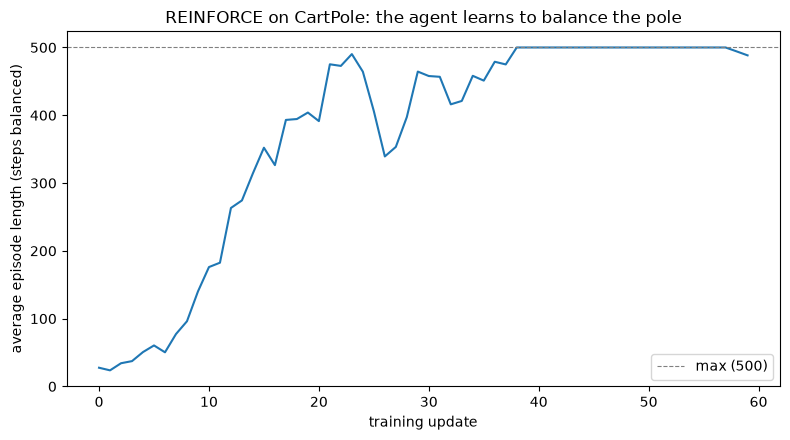

In [7]:
plt.figure(figsize=(8, 4.5))
plt.plot(avg_length)
plt.xlabel("training update")
plt.ylabel("average episode length (steps balanced)")
plt.title("REINFORCE on CartPole: the agent learns to balance the pole")
plt.axhline(500, color="gray", linestyle="--", linewidth=0.8, label="max (500)")
plt.legend()
plt.tight_layout()
plt.show()

The curve climbs from around twenty steps, barely better than random, to hundreds of steps as the policy improves, demonstrating that the agent genuinely learned to balance the pole from nothing but the reward signal. The path is not perfectly smooth, REINFORCE is a high-variance algorithm, which is exactly why more advanced methods such as PPO and actor-critic algorithms, all provided by TorchRL, are preferred for harder problems.

## Evaluating the Trained Agent

Training used sampled, exploratory actions. To measure the final policy we instead act *greedily*, always taking the most probable action, and run several fresh episodes to see how long the trained agent keeps the pole up.

In [8]:
lengths = []
with torch.no_grad(), set_exploration_type(ExplorationType.DETERMINISTIC):
    for _ in range(10):
        episode = env.rollout(max_steps=500, policy=actor)
        lengths.append(episode.shape[0])

print("Greedy episode lengths:", lengths)
print(f"Average over 10 evaluation episodes: {sum(lengths) / len(lengths):.1f} steps")

Greedy episode lengths: [444, 471, 500, 455, 402, 463, 423, 454, 410, 443]
Average over 10 evaluation episodes: 446.5 steps


Acting greedily, the trained agent balances the pole far longer than the random policy we started with, confirming that a useful behavior was learned. We used the simplest policy-gradient method and a small environment, but the same TorchRL components, environments, actors, collectors, and loss modules, scale up to the sophisticated algorithms used on robotics and game-playing benchmarks.

The next section returns to supervised networks and asks a practical deployment question: once a model is trained, how much of it can we throw away without hurting it? That is the topic of [Pruning Neural Networks](t81_558_class_13_4_pruning.ipynb).